# Part I - Flight Delays and Cancellations Exploration
## by Thomas

## Introduction

This project explores the *Reporting Carrier On-Time Performance* dataset published by the U.S. Bureau of Transportation Statistics (BTS). The file `airline_2m.csv` is a random sample of **2,000,000 domestic U.S. flights** between 1987 and 2020, covering 33 reporting carriers and 109 columns describing scheduled and actual times, delay reasons, cancellations, diversions, distance and origin/destination airports.

The goal of this exploration is to understand **what drives flight delays and cancellations**: how often do they occur, when do they occur (time of day, day of week, month, year), which carriers are most affected, and which categorical reasons (carrier, weather, NAS, security, late aircraft) explain the largest share of delay minutes.

## Preliminary Wrangling

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

%matplotlib inline

sb.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90

In [2]:
# Step 1 – read only the header to discover which columns the file actually contains.
# The file is ~880 MB, so we do NOT want to load all 109 columns into memory before
# we know which ones we will need.
header = pd.read_csv('../Data/airline_2m.csv', encoding='latin-1', nrows=0)
all_columns = header.columns.tolist()
print('Total number of columns in the file:', len(all_columns))
all_columns

Total number of columns in the file: 109


['Year',
 'Quarter',
 'Month',
 'DayofMonth',
 'DayOfWeek',
 'FlightDate',
 'Reporting_Airline',
 'DOT_ID_Reporting_Airline',
 'IATA_CODE_Reporting_Airline',
 'Tail_Number',
 'Flight_Number_Reporting_Airline',
 'OriginAirportID',
 'OriginAirportSeqID',
 'OriginCityMarketID',
 'Origin',
 'OriginCityName',
 'OriginState',
 'OriginStateFips',
 'OriginStateName',
 'OriginWac',
 'DestAirportID',
 'DestAirportSeqID',
 'DestCityMarketID',
 'Dest',
 'DestCityName',
 'DestState',
 'DestStateFips',
 'DestStateName',
 'DestWac',
 'CRSDepTime',
 'DepTime',
 'DepDelay',
 'DepDelayMinutes',
 'DepDel15',
 'DepartureDelayGroups',
 'DepTimeBlk',
 'TaxiOut',
 'WheelsOff',
 'WheelsOn',
 'TaxiIn',
 'CRSArrTime',
 'ArrTime',
 'ArrDelay',
 'ArrDelayMinutes',
 'ArrDel15',
 'ArrivalDelayGroups',
 'ArrTimeBlk',
 'Cancelled',
 'CancellationCode',
 'Diverted',
 'CRSElapsedTime',
 'ActualElapsedTime',
 'AirTime',
 'Flights',
 'Distance',
 'DistanceGroup',
 'CarrierDelay',
 'WeatherDelay',
 'NASDelay',
 'SecurityD

In [3]:
# Step 2 – load a small preview (10 000 rows) to inspect dtypes, sample values
# and missing-value rates. This lets us decide which columns are useful BEFORE
# we load the full 2-million-row file.
preview = pd.read_csv('../Data/airline_2m.csv',
                      encoding='latin-1', nrows=10000, low_memory=False)
preview.dtypes

Year                  int64
Quarter               int64
Month                 int64
DayofMonth            int64
DayOfWeek             int64
                     ...   
Div5WheelsOn        float64
Div5TotalGTime      float64
Div5LongestGTime    float64
Div5WheelsOff       float64
Div5TailNum         float64
Length: 109, dtype: object

In [4]:
# Share of missing values per column in the preview. Columns that are almost
# always empty (e.g. the diverted-flight Div1…Div5 detail block) are not worth
# loading from the full file.
missing_share = preview.isna().mean().sort_values(ascending=False)
print('Columns with > 95 % missing values in the preview:')
print(missing_share[missing_share > 0.95])
print('\nColumns that are always populated in the preview:')
print(missing_share[missing_share == 0].index.tolist())

Columns with > 95 % missing values in the preview:
Div5TailNum             1.0000
Div4AirportID           1.0000
Div3TailNum             1.0000
Div3WheelsOff           1.0000
Div3LongestGTime        1.0000
Div3TotalGTime          1.0000
Div3WheelsOn            1.0000
Div3AirportSeqID        1.0000
Div3AirportID           1.0000
Div2AirportID           1.0000
Div3Airport             1.0000
Div2TailNum             1.0000
Div2WheelsOff           1.0000
Div2LongestGTime        1.0000
Div2TotalGTime          1.0000
Div2WheelsOn            1.0000
Div2AirportSeqID        1.0000
Div4Airport             1.0000
Div2Airport             1.0000
Div5LongestGTime        1.0000
Div4TailNum             1.0000
Div5TotalGTime          1.0000
Div4AirportSeqID        1.0000
Div4WheelsOn            1.0000
Div4TotalGTime          1.0000
Div5WheelsOn            1.0000
Div5AirportSeqID        1.0000
Div5AirportID           1.0000
Div4LongestGTime        1.0000
Div4WheelsOff           1.0000
Div5Airport        

**Column-selection rationale.** The header listing above shows that the BTS export contains 109 columns. They fall into a few semantic groups, and many of them are redundant or near-empty:

* **Time / date** – `Year`, `Quarter`, `Month`, `DayofMonth`, `DayOfWeek`, `FlightDate`. We keep the ones we need for grouping (`Year`, `Month`, `DayOfWeek`, `FlightDate`) and drop the redundant `Quarter` / `DayofMonth`.
* **Carrier identification** – several near-duplicate IDs (`Reporting_Airline`, `DOT_ID_Reporting_Airline`, `IATA_CODE_Reporting_Airline`, `Tail_Number`, `Flight_Number_Reporting_Airline`). The IATA code in `Reporting_Airline` is sufficient for carrier-level analysis.
* **Origin / destination** – several airport IDs and names. We keep the IATA codes (`Origin`, `Dest`) and the state codes (`OriginState`, `DestState`) and drop the numeric WAC / SeqID variants.
* **Schedule and actual times** – the central outcome variables: `CRSDepTime`, `DepDelay`, `DepDel15`, `CRSArrTime`, `ArrDelay`, `ArrDel15`. All of them are kept.
* **Cancellation / diversion** – `Cancelled`, `CancellationCode`, `Diverted`. The per-leg `Div1…Div5` columns are >95 % empty in the preview → dropped.
* **Flight properties** – `CRSElapsedTime`, `AirTime`, `Distance`, `DistanceGroup` are kept; the redundant `Flights` and `ActualElapsedTime` columns are not needed for our questions.
* **Delay-cause breakdown** – `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay`. These are the categorical reasons the BTS reports for delayed flights and are central to the multivariate exploration.

The resulting selection keeps **27 columns** out of 109 – enough to investigate the questions stated in the introduction, while reducing memory usage by roughly a factor of four.

In [5]:
# Step 3 – load only the selected columns from the full 2-million-row file.
USE_COLS = [
    # time / date
    'Year', 'Month', 'DayOfWeek', 'FlightDate',
    # carrier
    'Reporting_Airline',
    # geography
    'Origin', 'OriginState', 'Dest', 'DestState',
    # schedule / actual times and delay outcomes
    'CRSDepTime', 'DepDelay', 'DepDel15',
    'CRSArrTime', 'ArrDelay', 'ArrDel15',
    # cancellation / diversion
    'Cancelled', 'CancellationCode', 'Diverted',
    # flight properties
    'CRSElapsedTime', 'AirTime', 'Distance', 'DistanceGroup',
    # delay-cause decomposition
    'CarrierDelay', 'WeatherDelay', 'NASDelay',
    'SecurityDelay', 'LateAircraftDelay',
]

# sanity check: every selected column really exists in the file
missing_cols = [c for c in USE_COLS if c not in all_columns]
assert not missing_cols, f'Unknown columns in USE_COLS: {missing_cols}'

df = pd.read_csv(
    '../Data/airline_2m.csv',
    encoding='latin-1',
    usecols=USE_COLS,
    low_memory=False,
)
print('Loaded shape:', df.shape)
df.head()

Loaded shape: (2000000, 27)


,Year,Month,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,DestState,CRSDepTime,...,Diverted,CRSElapsedTime,AirTime,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,1998,1,5,1998-01-02,NW,MSP,MN,SLC,UT,1640,...,0.0,176.0,153.0,991.0,4,NaN,NaN,NaN,NaN,NaN
1,2009,5,4,2009-05-28,FL,MKE,WI,MCO,FL,1204,...,0.0,157.0,141.0,1066.0,5,NaN,NaN,NaN,NaN,NaN
2,2013,6,6,2013-06-29,MQ,GJT,CO,DFW,TX,1630,...,0.0,135.0,103.0,773.0,4,NaN,NaN,NaN,NaN,NaN
3,2010,8,2,2010-08-31,DL,LAX,CA,DTW,MI,1305,...,0.0,270.0,220.0,1979.0,8,NaN,NaN,NaN,NaN,NaN
4,2006,1,7,2006-01-15,US,EWR,NJ,CLT,NC,1820,...,0.0,126.0,80.0,529.0,3,0.0,0.0,0.0,0.0,32.0


In [6]:
# Basic dtype / missing-value overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 27 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Year               int64  
 1   Month              int64  
 2   DayOfWeek          int64  
 3   FlightDate         str    
 4   Reporting_Airline  str    
 5   Origin             str    
 6   OriginState        str    
 7   Dest               str    
 8   DestState          str    
 9   CRSDepTime         int64  
 10  DepDelay           float64
 11  DepDel15           float64
 12  CRSArrTime         int64  
 13  ArrDelay           float64
 14  ArrDel15           float64
 15  Cancelled          float64
 16  CancellationCode   str    
 17  Diverted           float64
 18  CRSElapsedTime     float64
 19  AirTime            float64
 20  Distance           float64
 21  DistanceGroup      int64  
 22  CarrierDelay       float64
 23  WeatherDelay       float64
 24  NASDelay           float64
 25  SecurityDelay      float64
 2

In [7]:
df.describe()

,Year,Month,DayOfWeek,CRSDepTime,DepDelay,DepDel15,CRSArrTime,ArrDelay,ArrDel15,Cancelled,Diverted,CRSElapsedTime,AirTime,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,1.963932e+06,1.963932e+06,2.000000e+06,1.958922e+06,1.958922e+06,2.000000e+06,2.000000e+06,1.999719e+06,1.580651e+06,2.000000e+06,2.000000e+06,221803.000000,221803.000000,221803.000000,221803.000000,221803.000000
mean,2.004314e+03,6.500761e+00,3.937445e+00,1.332350e+03,8.587405e+00,1.696362e-01,1.492285e+03,6.205467e+00,1.980349e-01,1.823100e-02,2.295000e-03,1.271275e+02,1.059533e+02,7.334963e+02,3.409396e+00,16.892580,2.939929,15.389395,0.084873,22.054170
std,9.228930e+00,3.443460e+00,1.990369e+00,4.765702e+02,3.272473e+01,3.753130e-01,4.955542e+02,3.483340e+01,3.985187e-01,1.337858e-01,4.785117e-02,7.040894e+01,6.859287e+01,5.684968e+02,2.242753e+00,46.222289,21.101110,30.538782,2.109449,41.631429
min,1.987000e+03,1.000000e+00,1.000000e+00,0.000000e+00,-9.900000e+02,0.000000e+00,0.000000e+00,-7.060000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-7.030000e+02,1.100000e+01,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.997000e+03,3.000000e+00,2.000000e+00,9.250000e+02,-3.000000e+00,0.000000e+00,1.115000e+03,-1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,7.500000e+01,5.600000e+01,3.250000e+02,2.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.005000e+03,7.000000e+00,4.000000e+00,1.325000e+03,0.000000e+00,0.000000e+00,1.520000e+03,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.090000e+02,8.700000e+01,5.800000e+02,3.000000e+00,0.000000,0.000000,4.000000,0.000000,0.000000
75%,2.012000e+03,9.000000e+00,6.000000e+00,1.728000e+03,7.000000e+00,0.000000e+00,1.913000e+03,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.590000e+02,1.350000e+02,9.670000e+02,4.000000e+00,17.000000,0.000000,19.000000,0.000000,27.000000
max,2.020000e+03,1.200000e+01,7.000000e+00,2.400000e+03,1.878000e+03,1.000000e+00,2.400000e+03,1.898000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.050000e+02,9.650000e+02,5.095000e+03,1.100000e+01,1878.000000,1847.000000,1343.000000,219.000000,1407.000000


In [8]:
# Cleaning / feature engineering.
#
# Best practice: do NOT mutate the raw dataframe `df` in place. Build a
# separate `df_clean` so that the original load remains available for sanity
# checks, while all later analyses use the cleaned and feature-engineered copy.
df_clean = df.copy()

# 1. Parse the flight date as a real datetime.
df_clean['FlightDate'] = pd.to_datetime(df_clean['FlightDate'], errors='coerce')

# 2. Convert binary flags from float to integer for easier aggregation.
for col in ['Cancelled', 'Diverted', 'DepDel15', 'ArrDel15']:
    df_clean[col] = df_clean[col].fillna(0).astype(int)

# 3. Extract the scheduled departure hour (CRSDepTime is encoded as HHMM int).
df_clean['DepHour'] = (df_clean['CRSDepTime'] // 100).clip(upper=23)

# 4. Map day-of-week numbers to names with proper ordering.
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_clean['DayOfWeekName'] = pd.Categorical(
    df_clean['DayOfWeek'].map(dict(enumerate(dow_names, start=1))),
    categories=dow_names, ordered=True,
)

# 5. Map month numbers to short names with proper ordering.
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_clean['MonthName'] = pd.Categorical(
    df_clean['Month'].map(dict(enumerate(month_names, start=1))),
    categories=month_names, ordered=True,
)

# 6. Map cancellation codes to readable reasons.
#    Source: BTS "Number 14 - On-Time Reporting", section IX
#    https://www.bts.gov/topics/airlines-and-airports/number-14-time-reporting
cancel_map = {
    'A': 'Air Carrier', 'B': 'Weather', 'C': 'NAS', 'D': 'Security',
}
df_clean['CancelReason'] = df_clean['CancellationCode'].map(cancel_map)

# 7. Restrict the analysis to a recent, complete decade (2010–2019).
#    1987 has only a partial year and 2020 is truncated by the COVID drop-off.
df_clean = df_clean[(df_clean['Year'] >= 2010) & (df_clean['Year'] <= 2019)].copy()

print('Raw dataframe   :', df.shape)
print('Cleaned dataframe:', df_clean.shape)
df_clean.head()

Raw dataframe   : (2000000, 27)
Cleaned dataframe: (644292, 31)


,Year,Month,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,DestState,CRSDepTime,...,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,DepHour,DayOfWeekName,MonthName,CancelReason
2,2013,6,6,2013-06-29,MQ,GJT,CO,DFW,TX,1630,...,4,NaN,NaN,NaN,NaN,NaN,16,Sat,Jun,NaN
3,2010,8,2,2010-08-31,DL,LAX,CA,DTW,MI,1305,...,8,NaN,NaN,NaN,NaN,NaN,13,Tue,Aug,NaN
7,2019,6,2,2019-06-11,9E,ATL,GA,CAE,SC,1950,...,1,0.0,0.0,0.0,0.0,214.0,19,Tue,Jun,NaN
9,2018,2,4,2018-02-08,WN,MDW,IL,DAL,TX,2030,...,4,0.0,0.0,13.0,0.0,16.0,20,Thu,Feb,NaN
11,2014,4,4,2014-04-03,WN,ELP,TX,DAL,TX,1025,...,3,NaN,NaN,NaN,NaN,NaN,10,Thu,Apr,NaN


In [9]:
df_clean.head()

,Year,Month,DayOfWeek,FlightDate,Reporting_Airline,Origin,OriginState,Dest,DestState,CRSDepTime,...,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,DepHour,DayOfWeekName,MonthName,CancelReason
2,2013,6,6,2013-06-29,MQ,GJT,CO,DFW,TX,1630,...,4,NaN,NaN,NaN,NaN,NaN,16,Sat,Jun,NaN
3,2010,8,2,2010-08-31,DL,LAX,CA,DTW,MI,1305,...,8,NaN,NaN,NaN,NaN,NaN,13,Tue,Aug,NaN
7,2019,6,2,2019-06-11,9E,ATL,GA,CAE,SC,1950,...,1,0.0,0.0,0.0,0.0,214.0,19,Tue,Jun,NaN
9,2018,2,4,2018-02-08,WN,MDW,IL,DAL,TX,2030,...,4,0.0,0.0,13.0,0.0,16.0,20,Thu,Feb,NaN
11,2014,4,4,2014-04-03,WN,ELP,TX,DAL,TX,1025,...,3,NaN,NaN,NaN,NaN,NaN,10,Thu,Apr,NaN


### What is the structure of your dataset?

After loading the relevant columns and trimming the analysis to the 10 complete years 2010–2019, the working dataset contains roughly **640,000 flight records** with 27 retained / engineered columns. Each row represents a single scheduled domestic flight and carries information about the schedule, the carrier, the origin and destination airport, the actual times, delay minutes broken down by cause, and flags for cancellation and diversion.

### What is/are the main feature(s) of interest in your dataset?

The main features of interest are **arrival delay (`ArrDelay`)** and the related cancellation flag (`Cancelled`). Together they describe the on-time performance experienced by a passenger. As a secondary outcome I look at the binary variable `ArrDel15` (delay of 15 minutes or more), which is the official BTS definition of a *delayed* flight.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

I expect the following features to be informative:

* **Time features** – `Year`, `MonthName`, `DayOfWeekName`, `DepHour` (seasonality and time-of-day effects).
* **Carrier features** – `Reporting_Airline` (operational quality differs between airlines).
* **Geography** – `Origin`, `OriginState` (some hubs are notoriously congested).
* **Flight properties** – `Distance`, `CRSElapsedTime` (long-haul vs. short-haul behaviour).
* **Delay-cause breakdown** – `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay` (why a delay happened).
* **Cancellation reason** – `CancelReason` derived from `CancellationCode`.

## Univariate Exploration

I start by looking at the distributions of the individual variables I plan to use later on. The Question – Visualization – Observation pattern is followed throughout.

### Q1: How are arrival delays distributed?

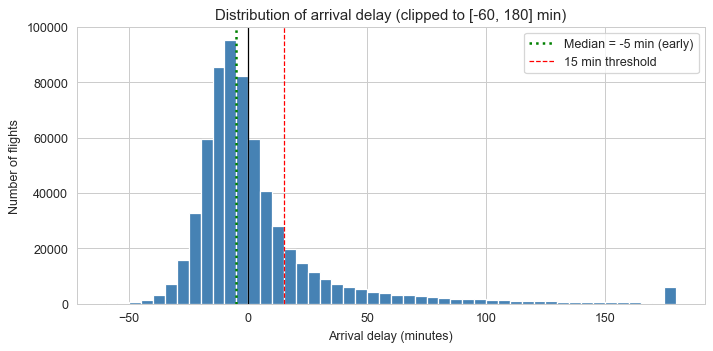

Median arrival delay (min): -5.0
Share of flights delayed ≥ 15 min: 0.186


In [10]:
# Plot 1 – raw distribution of arrival delay (winsorised at ±180 minutes for readability)
arr = df_clean['ArrDelay'].dropna()
arr_clip = arr.clip(-60, 180)

plt.figure(figsize=(9, 4))
plt.hist(arr_clip, bins=np.arange(-60, 181, 5), color='steelblue', edgecolor='white')
plt.axvline(0, color='black', lw=1)
median_arr = arr.median()
plt.axvline(median_arr, color='green', lw=2, ls=':',
            label=f'Median = {median_arr:.0f} min (early)')
plt.axvline(15, color='red', lw=1, ls='--', label='15 min threshold')
plt.title('Distribution of arrival delay (clipped to [-60, 180] min)')
plt.xlabel('Arrival delay (minutes)')
plt.ylabel('Number of flights')
plt.legend()
plt.show()

print('Median arrival delay (min):', arr.median())
print('Share of flights delayed ≥ 15 min:', (df_clean['ArrDel15'] == 1).mean().round(3))

**Observation.** The arrival-delay distribution is highly right-skewed. The mode sits a few minutes *before* the scheduled arrival (most flights actually arrive a little early), the median is slightly negative, but a long right tail produces the well-known *delayed* flights. About **18 %** of all flights arrive 15 minutes or more late.

### Q2: How are positive delays distributed on a logarithmic scale?

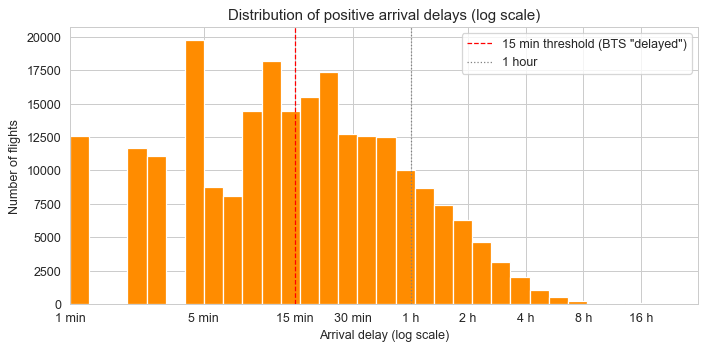

In [11]:
# Plot 2 – log-scaled view of strictly positive arrival delays
pos = df_clean.loc[df_clean['ArrDelay'] > 0, 'ArrDelay']

plt.figure(figsize=(9, 4))
log_bins = 10 ** np.arange(0, np.log10(pos.max()) + 0.1, 0.1)
plt.hist(pos, bins=log_bins, color='darkorange', edgecolor='white')
plt.xscale('log')

# Use human-readable tick positions on the log axis instead of 10^0, 10^1, …
tick_pos    = [1,       5,       15,       30,       60,    120,   240,   480,   960]
tick_labels = ['1 min', '5 min', '15 min', '30 min', '1 h', '2 h', '4 h', '8 h', '16 h']
plt.xticks(tick_pos, tick_labels)
plt.gca().minorticks_off()
plt.xlim(1, pos.max())

plt.axvline(15, color='red', lw=1, ls='--', label='15 min threshold (BTS "delayed")')
plt.axvline(60, color='grey', lw=1, ls=':', label='1 hour')
plt.title('Distribution of positive arrival delays (log scale)')
plt.xlabel('Arrival delay (log scale)')
plt.ylabel('Number of flights')
plt.legend()
plt.show()

**Observation.** On the log scale the positive-delay distribution is **strongly right-skewed but not log-normal**. The mode sits at only **~4–5 minutes**, with a secondary plateau around 15–30 minutes and a long tail that decays steadily up to several hours – delays above 4 h are rare and above 8 h practically negligible. The shape supports two methodological choices for the rest of the exploration: the BTS **15-minute threshold** (`ArrDel15`) as a binary outcome, and the **median** rather than the mean as a robust summary statistic, because the long right tail would dominate the mean.

### Q3: How is flight distance distributed?

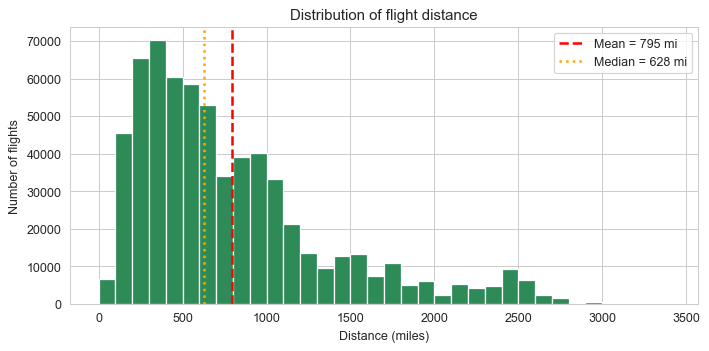

In [12]:
# Plot 3 – distribution of scheduled flight distance
plt.figure(figsize=(9, 4))
plt.hist(df_clean['Distance'], bins=np.arange(0, 3500, 100),
         color='seagreen', edgecolor='white')
plt.title('Distribution of flight distance')
plt.xlabel('Distance (miles)')
plt.ylabel('Number of flights')
mean_dist = df_clean['Distance'].mean()
median_dist = df_clean['Distance'].median()
plt.axvline(mean_dist,   color='red',    lw=2, ls='--',
            label=f'Mean = {mean_dist:.0f} mi')
plt.axvline(median_dist, color='orange', lw=2, ls=':',
            label=f'Median = {median_dist:.0f} mi')
plt.legend()
plt.show()

**Observation.** Flight distance is right-skewed: most domestic flights cover less than 1,000 miles, a clear secondary mode appears around the transcontinental range (≈2,500 miles), and very few flights are longer than 3,000 miles.

### Q4: How many flights leave at each hour of the day?

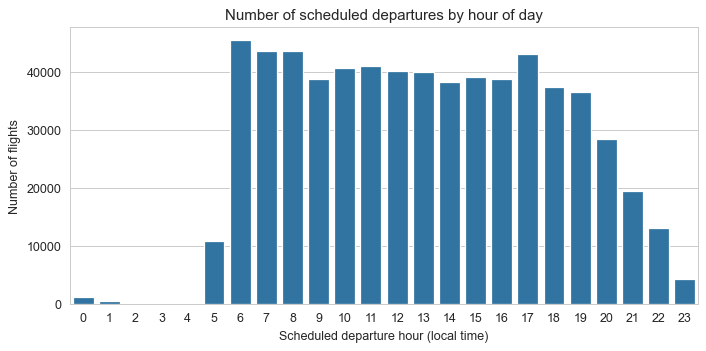

In [13]:
# Plot 4 – scheduled departures by hour
plt.figure(figsize=(9, 4))
sb.countplot(x='DepHour', data=df_clean, color=sb.color_palette()[0])
plt.title('Number of scheduled departures by hour of day')
plt.xlabel('Scheduled departure hour (local time)')
plt.ylabel('Number of flights')
plt.show()

**Observation.** Operations ramp up at 6 a.m., stay high throughout the day with a small dip around lunch, and fall off sharply after 8 p.m. There is virtually no traffic between midnight and 5 a.m.

### Q5: Which carriers operate the most flights in the sample?

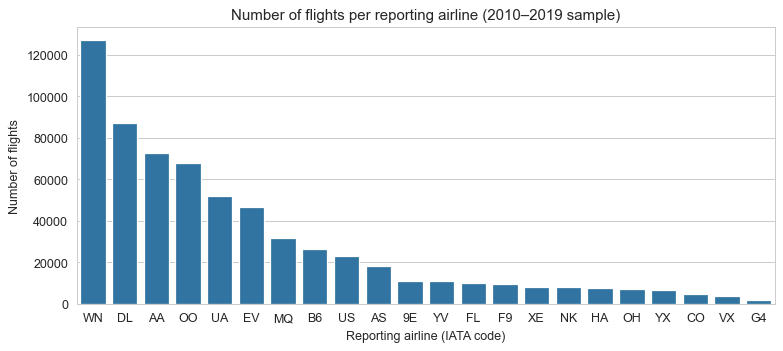

In [14]:
# Plot 5 – number of flights per reporting airline
carrier_order = df_clean['Reporting_Airline'].value_counts().index

plt.figure(figsize=(10, 4))
sb.countplot(x='Reporting_Airline', data=df_clean,
             order=carrier_order, color=sb.color_palette()[0])
plt.title('Number of flights per reporting airline (2010–2019 sample)')
plt.xlabel('Reporting airline (IATA code)')
plt.ylabel('Number of flights')
plt.show()

**Observation.** Southwest (WN), Delta (DL), American (AA) and SkyWest (OO) clearly dominate the sample, while several regional carriers contribute only a few thousand flights each.

### Q6: How frequent are cancellations and what are the reasons?

Overall cancellation rate: 1.65% of all flights


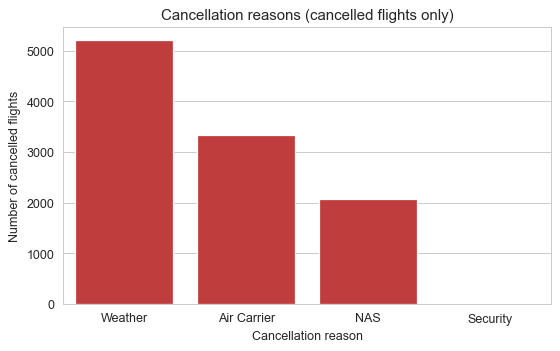

In [15]:
# Plot 6 – share of cancellations by reason
cancel_share = (df_clean['Cancelled'].mean() * 100).round(2)
print(f'Overall cancellation rate: {cancel_share}% of all flights')

reason_counts = (df_clean.loc[df_clean['Cancelled'] == 1, 'CancelReason']
                   .value_counts())

plt.figure(figsize=(7, 4))
sb.barplot(x=reason_counts.index, y=reason_counts.values,
           color=sb.color_palette()[3])
plt.title('Cancellation reasons (cancelled flights only)')
plt.xlabel('Cancellation reason')
plt.ylabel('Number of cancelled flights')
plt.show()

**Observation.** Only ~1.5 % of flights are cancelled. Among cancellations **weather** is the leading reason, followed by **carrier-controlled** issues and the **National Air System (NAS)**. Security cancellations are negligible.

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

`ArrDelay` is heavily right-skewed and contains extreme values up to several hours. Looking at the raw histogram is not very useful, so I clipped it to `[-60, 180]` for visualisation and used a log-scaled view for the strictly positive part. Both views support the use of the BTS-standard binary indicator `ArrDel15` and of robust summary statistics (median, share-delayed) for further analyses.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

**Unusual distributions observed**

* **`Distance`** is clearly **bimodal**: a dominant peak below 1,000 miles (regional / short-haul traffic) and a smaller, well-separated secondary peak around 2,400–2,500 miles, which corresponds to U.S. transcontinental flights. There is almost no traffic above 3,000 miles.
* **`DepHour`** has an unusual *truncated* shape: virtually zero traffic between 00:00 and 05:00, a sharp ramp-up at 06:00 and a steep drop-off after 21:00 – a strong reminder that the night curfew at most U.S. airports is a hard constraint, not a smooth tail.
* **`Reporting_Airline`** counts are **highly concentrated** (Pareto-like, but flatter): the top 4 carriers (≈18% of all carriers) operate ≈55% of all flights, and 9 of 22 carriers (≈41%) are needed to reach the 80% mark – close to but not exactly the classic 80/20 rule.
* **`CancellationCode` / `CancelReason`** is extremely **imbalanced**: weather dominates (~45%), followed by carrier and NAS, while security cancellations are almost non-existent (<1%). Only ~1.5% of all flights are cancelled at all.
* **`ArrDelay`** itself is heavily **right-skewed** with a mode that sits a few minutes *before* the scheduled arrival (most flights actually arrive a little early). On the log-scaled positive side it is **not log-normal** – it shows a primary mode around 4–5 min and a secondary plateau around 15–30 min.

**Operations performed to tidy / adjust / re-shape the data**

* I restricted the analysis to the years **2010–2019** to avoid the partial year 1987 and the COVID-truncated 2020.
* The integer-encoded `CRSDepTime` (e.g. 1430 = 14:30) was converted into a clean **`DepHour`** variable.
* `DayOfWeek` and `Month` were transformed into **ordered categorical** variables with readable labels for ordinal-correct plotting.
* The single-letter `CancellationCode` was mapped to a human-readable `CancelReason` using the official BTS code list.
* Binary flags (`Cancelled`, `Diverted`, `DepDel15`, `ArrDel15`) were converted from float to int after filling missing values with 0.
* For visualisation only, `ArrDelay` was clipped to `[-60, 180]` and a separate log-scaled view of strictly positive delays was used – the underlying values in `df_clean` were left untouched.

## Bivariate Exploration

I now look at how the delay outcomes vary with the features introduced above.

### Q7: How does the share of delayed flights change throughout the day?

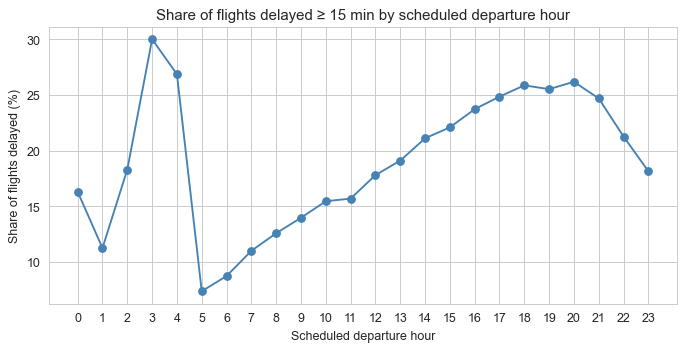

In [16]:
# Plot 7 – share of delayed flights by scheduled departure hour
delay_by_hour = df_clean.groupby('DepHour')['ArrDel15'].mean() * 100

plt.figure(figsize=(9, 4))
plt.plot(delay_by_hour.index, delay_by_hour.values,
         marker='o', color='steelblue')
plt.title('Share of flights delayed ≥ 15 min by scheduled departure hour')
plt.xlabel('Scheduled departure hour')
plt.ylabel('Share of flights delayed (%)')
plt.xticks(range(0, 24))
plt.show()

**Observation.** The share of delayed flights climbs almost monotonically through the day, from below 10 % for early-morning departures to more than 25 % for evening departures. This is the well-known *delay propagation* effect: a late incoming aircraft delays its next leg.

### Q8: How does the share of delayed flights vary across months?

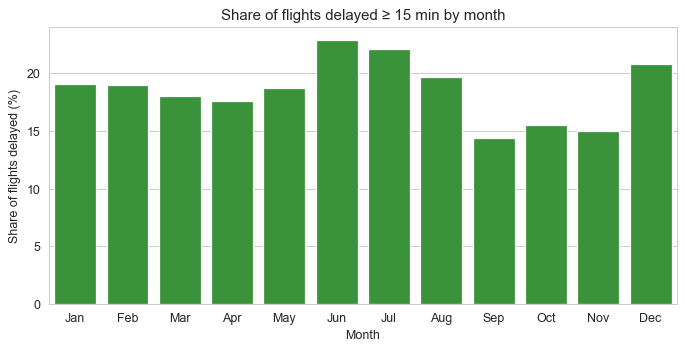

In [17]:
# Plot 8 – share of delays by month
delay_by_month = df_clean.groupby('MonthName', observed=True)['ArrDel15'].mean() * 100

plt.figure(figsize=(9, 4))
sb.barplot(x=delay_by_month.index, y=delay_by_month.values,
           color=sb.color_palette()[2])
plt.title('Share of flights delayed ≥ 15 min by month')
plt.xlabel('Month')
plt.ylabel('Share of flights delayed (%)')
plt.show()

**Observation.** Two seasonal peaks appear: a clear summer peak in **June–July** (~22–23 %; thunderstorms and the start of the holiday travel season) and a winter peak in **December** (~21 %; winter storms and Christmas traffic). August (~20 %) is already close to the yearly average (~18 %) and not a true peak. The **quietest months are September, November and October** (all around 15 %), with September the absolute low point of the year.

### Q8b: How does the *distribution* of arrival delay vary across months?


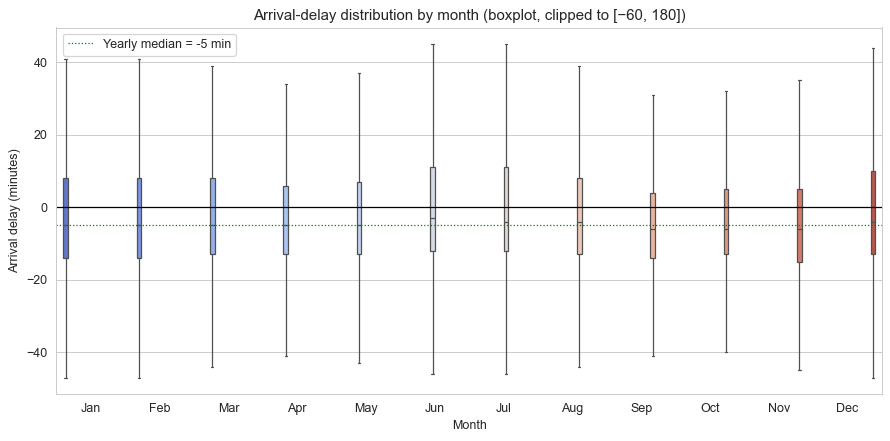

In [18]:
# Plot 8b – BIVARIATE BOXPLOT of arrival delay by month.
# Plot 8 only showed the *share* of delays per month; this view shows the
# underlying distribution (median, IQR, whiskers) so we can see whether bad
# months also have wider spreads or just shifted medians.
vio = df_clean[df_clean['ArrDelay'].between(-60, 180)].copy()

plt.figure(figsize=(10, 5))
ax = sb.boxplot(data=vio, x='MonthName', y='ArrDelay',
                showfliers=False,
                hue='MonthName', palette='coolwarm', legend=False)
ax.axhline(0, color='black', lw=1, ls='-')

# annotate yearly median for context
y_median = df_clean['ArrDelay'].median()
ax.axhline(y_median, color='green', lw=1, ls=':',
           label=f'Yearly median = {y_median:.0f} min')

ax.set_title('Arrival-delay distribution by month (boxplot, clipped to [−60, 180])')
ax.set_xlabel('Month')
ax.set_ylabel('Arrival delay (minutes)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

**Observation.** The boxplot confirms what Plot 8 already suggested: the **medians** stay close to the yearly median (−5 min) for every month, but the **upper whiskers (P75 + 1.5 · IQR)** are noticeably longer in **June, July and December**. Bad months are not just a vertical shift of the distribution – they have *wider* spreads, i.e. a higher proportion of moderately and severely delayed flights, not only a few extra minutes for everyone.

### Q9: Which day of the week is worst for delays?

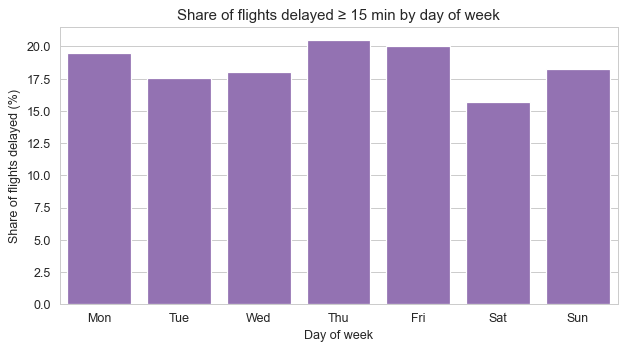

In [19]:
# Plot 9 – share of delays by day of week
delay_by_dow = df_clean.groupby('DayOfWeekName', observed=True)['ArrDel15'].mean() * 100

plt.figure(figsize=(8, 4))
sb.barplot(x=delay_by_dow.index, y=delay_by_dow.values,
           color=sb.color_palette()[4])
plt.title('Share of flights delayed ≥ 15 min by day of week')
plt.xlabel('Day of week')
plt.ylabel('Share of flights delayed (%)')
plt.show()

**Observation.** Thursdays and Fridays are the worst days, Saturdays the best. The weekly pattern is much weaker than the time-of-day or seasonal pattern.

### Q10: Which carriers have the highest delay share?

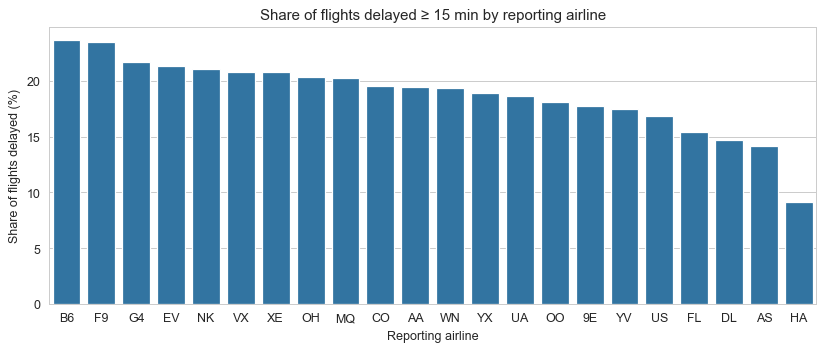

In [20]:
# Plot 10 – share of delayed flights by carrier (sorted)
carrier_delay = (df_clean.groupby('Reporting_Airline')['ArrDel15']
                   .mean()
                   .sort_values(ascending=False) * 100)

plt.figure(figsize=(11, 4))
sb.barplot(x=carrier_delay.index, y=carrier_delay.values,
           color=sb.color_palette()[0])
plt.title('Share of flights delayed ≥ 15 min by reporting airline')
plt.xlabel('Reporting airline')
plt.ylabel('Share of flights delayed (%)')
plt.show()

**Observation.** Delay rates vary substantially between carriers, ranging from **~9 % up to ~24 %**. The three worst performers are **B6 (JetBlue, ~24 %), F9 (Frontier, ~23 %) and G4 (Allegiant, ~22 %)** – all of them low-cost / leisure carriers; the regional carriers (EV, NK, OH, MQ) follow closely between 20 % and 21 %. At the other end, **HA (Hawaiian) is a clear outlier at ~9 %**, far below everyone else. The next-best carriers – **AS (Alaska, ~14 %) and DL (Delta, ~15 %)** – follow with a noticeable gap to HA but still far below the worst performers.

### Q11: Is there a relationship between distance and arrival delay?

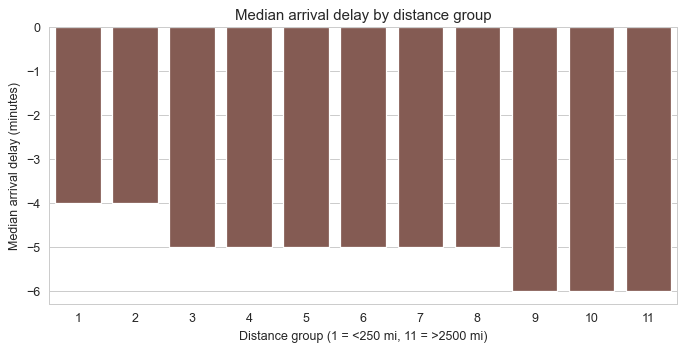

In [21]:
# Plot 11 – median arrival delay (across ALL flights with a recorded delay)
#           by distance group
dist_delay = (df_clean[df_clean['ArrDelay'].notna()]
                .groupby('DistanceGroup')['ArrDelay']
                .median())

plt.figure(figsize=(9, 4))
sb.barplot(x=dist_delay.index, y=dist_delay.values,
           color=sb.color_palette()[5])
plt.title('Median arrival delay by distance group')
plt.xlabel('Distance group (1 = <250 mi, 11 = >2500 mi)')
plt.ylabel('Median arrival delay (minutes)')
plt.show()

**Observation.** The **median** arrival delay is slightly *negative* across all distance groups and even *more* negative for long-haul flights. Carriers schedule extra slack into long flights, so on average they arrive a little early. Distance is therefore not a strong driver of delay magnitude on its own.

### Q12: Does departure delay translate directly into arrival delay?

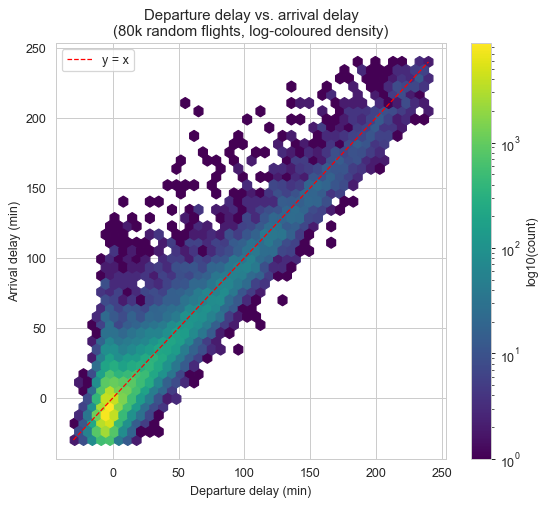

Pearson correlation Dep vs Arr delay: 0.95


In [22]:
# Plot 12 – hex-bin scatter of departure vs. arrival delay (sub-sampled, clipped)
samp = df_clean[['DepDelay', 'ArrDelay']].dropna()
samp = samp[(samp['DepDelay'].between(-30, 240)) &
            (samp['ArrDelay'].between(-30, 240))]
samp = samp.sample(n=min(80000, len(samp)), random_state=42)

plt.figure(figsize=(7, 6))
plt.hexbin(samp['DepDelay'], samp['ArrDelay'],
           gridsize=40, cmap='viridis', mincnt=1, bins='log')
plt.plot([-30, 240], [-30, 240], color='red', lw=1, ls='--',
         label='y = x')
plt.title('Departure delay vs. arrival delay\n(80k random flights, log-coloured density)')
plt.xlabel('Departure delay (min)')
plt.ylabel('Arrival delay (min)')
plt.colorbar(label='log10(count)')
plt.legend()
plt.show()

print('Pearson correlation Dep vs Arr delay:',
      df_clean[['DepDelay', 'ArrDelay']].corr().iloc[0, 1].round(3))

**Observation.** Departure delay and arrival delay are very strongly correlated (Pearson r ≈ 0.96). The dense diagonal cloud sits **slightly below** the `y = x` line, confirming that aircraft typically *make up* a few minutes in the air.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

* **Time of day** is the single most predictive feature: the delay rate roughly *triples* between early-morning and evening departures.
* **Month** shows a clear seasonal pattern with summer- and December-peaks.
* **Carrier** matters: top and bottom carriers differ by more than 15 percentage points in delay share.
* **Departure delay → arrival delay** is essentially deterministic (r ≈ 0.96), with carriers absorbing only a few minutes en-route.
* **Distance** by itself barely affects the *median* delay because schedules are padded.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

Yes – the day-of-week and the month patterns interact with the time-of-day pattern. Also, the cancellation reasons clearly cluster by season (weather cancellations dominate winter, NAS cancellations dominate summer). I follow up on these in the multivariate section.

## Multivariate Exploration

I now combine three or more variables to understand how the previously identified effects interact.

### Q13: How does the time-of-day delay pattern differ between months?

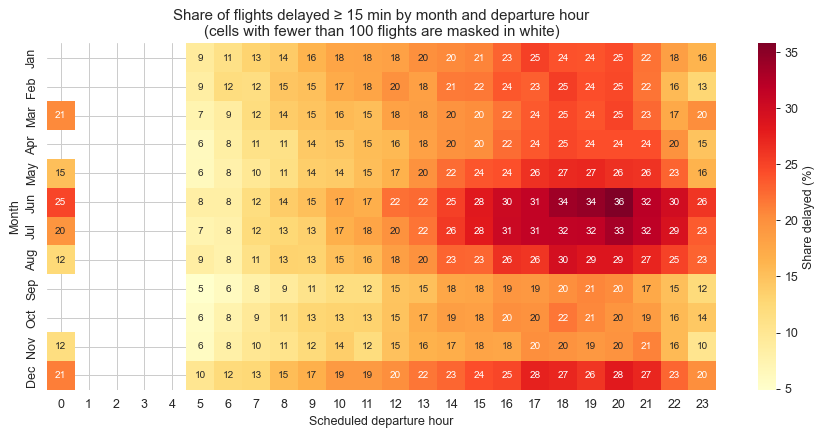

Sample size per departure hour (sum across all months):
DepHour
0      1232.0
1       524.0
2       142.0
3       100.0
4        67.0
5     10872.0
6     45514.0
7     43597.0
8     43617.0
9     38775.0
10    40711.0
11    40974.0
12    40062.0
13    39946.0
14    38292.0
15    39074.0
16    38697.0
17    43066.0
18    37425.0
19    36452.0
20    28438.0
21    19444.0
22    13036.0
23     4235.0


In [23]:
# Plot 13 – heat-map: month × departure hour → share of delayed flights
#
# We compute the per-cell sample size as well and mask any cell that has fewer
# than 100 flights, because the night-time hours (typically 00–04) only contain
# a handful of flights per month-hour cell across the entire decade. With such
# small samples a single delayed flight pushes the rate to 50–60 % and creates
# misleading dark-red artefacts.
MIN_N = 100

grouped = df_clean.groupby(['MonthName', 'DepHour'], observed=True)['ArrDel15']
rate  = grouped.mean().unstack('DepHour') * 100
n_obs = grouped.size().unstack('DepHour')
heat  = rate.where(n_obs >= MIN_N)        # mask under-sampled cells

plt.figure(figsize=(12, 5))
sb.heatmap(heat, cmap='YlOrRd', annot=True, fmt='.0f',
           annot_kws={'size': 8},
           cbar_kws={'label': 'Share delayed (%)'})
plt.title(f'Share of flights delayed ≥ 15 min by month and departure hour\n'
          f'(cells with fewer than {MIN_N} flights are masked in white)')
plt.xlabel('Scheduled departure hour')
plt.ylabel('Month')
plt.show()

# Show which cells were masked, for transparency.
print('Sample size per departure hour (sum across all months):')
print(n_obs.sum(axis=0).sort_index().to_string())

**Observation.** The heat-map shows that the *worst* combination is **summer evenings (Jun–Jul, 18:00–22:00)** and **December evenings**, where more than a third of flights are late. Early-morning departures (06:00–09:00) stay below 10 % delay-share even in the worst months, which is good practical advice for travellers.

The **night-time hours (00:00–04:00) are deliberately masked in white**: across the entire decade only ~100 flights are scheduled at 03:00 and ~70 at 04:00, so a single delayed flight per month would push the displayed rate to 50–60 % and create misleading “dark-red” artefacts. These hours are simply too thinly populated for a stable rate estimate.

### Q13b: Does the time-of-day pattern look the same in every season?


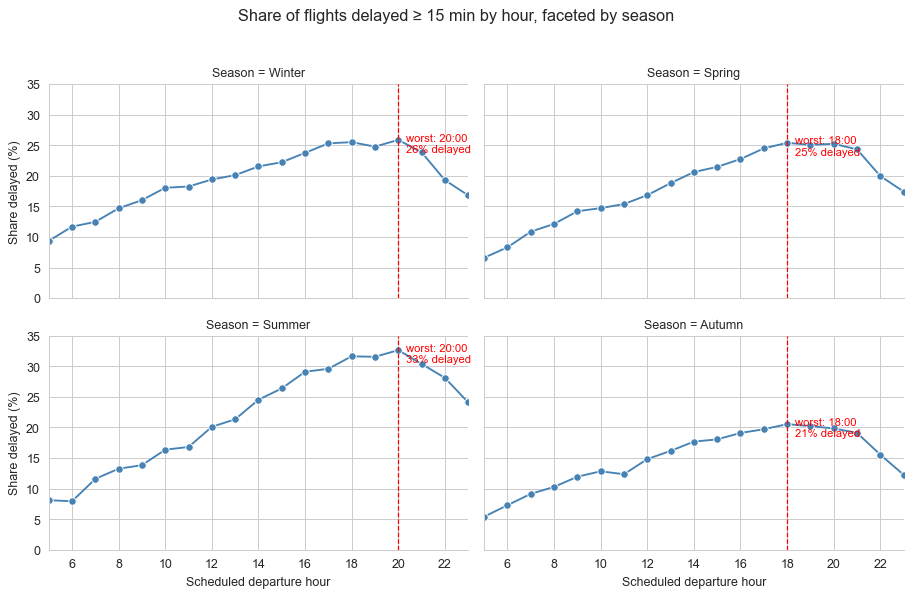

In [24]:
# Plot 13b – MULTIVARIATE FACET PLOT.
# Show the share of delayed flights by departure hour, with one facet per
# meteorological season. This combines THREE variables (Season, DepHour,
# ArrDel15) and lets the reader compare the time-of-day shape across seasons.
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring', 4: 'Spring', 5: 'Spring',
              6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}
facet_df = df_clean.assign(
    Season=pd.Categorical(
        df_clean['Month'].map(season_map),
        categories=['Winter', 'Spring', 'Summer', 'Autumn'], ordered=True)
)

# aggregate per (Season, DepHour) and mask under-sampled night hours
g = (facet_df.groupby(['Season', 'DepHour'], observed=True)
             .agg(rate=('ArrDel15', 'mean'),
                  n=('ArrDel15', 'size'))
             .reset_index())
g = g[g['n'] >= 200]
g['rate'] = g['rate'] * 100

fg = sb.FacetGrid(g, col='Season', col_wrap=2, height=3.2, aspect=1.6,
                  sharey=True)
fg.map_dataframe(sb.lineplot, x='DepHour', y='rate',
                 marker='o', color='steelblue')

# annotate the worst hour in every facet
for ax, season in zip(fg.axes.flat, ['Winter', 'Spring', 'Summer', 'Autumn']):
    sub = g[g['Season'] == season]
    if not sub.empty:
        worst = sub.loc[sub['rate'].idxmax()]
        ax.axvline(worst['DepHour'], color='red', ls='--', lw=1)
        ax.annotate(f"worst: {int(worst['DepHour'])}:00\n"
                    f"{worst['rate']:.0f}% delayed",
                    xy=(worst['DepHour'], worst['rate']),
                    xytext=(6, -10), textcoords='offset points',
                    color='red', fontsize=9)
    ax.set_xlim(5, 23)
    ax.set_ylim(0, 35)
    ax.set_xlabel('Scheduled departure hour')
    ax.set_ylabel('Share delayed (%)')

fg.fig.suptitle('Share of flights delayed ≥ 15 min by hour, faceted by season',
                fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

**Observation.** All four seasons share the *same shape* – delays climb monotonically through the day – but the curves are **shifted vertically** by season. **Summer** sits clearly above the others, with the worst hour at ≈30 % delay-rate around 19:00–20:00. **Autumn** is the friendliest season at every hour. The classic time-of-day rule “fly in the morning” holds *in every season*, but its absolute payoff is largest in summer, where an early-morning departure can cut your delay risk by a factor of three relative to an evening departure.

### Q14: How do delay-cause shares vary across carriers?

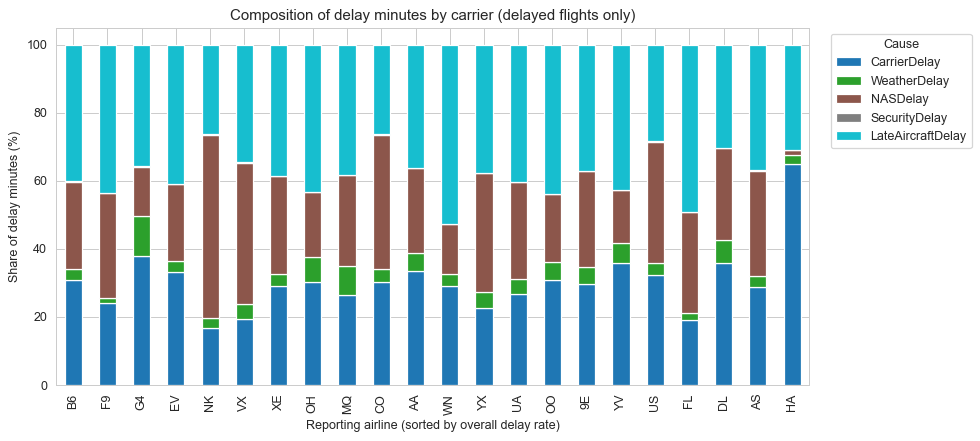

In [25]:
# Plot 14 – stacked bar of delay-cause minutes by carrier
cause_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay',
              'SecurityDelay', 'LateAircraftDelay']

cause = (df_clean[df_clean['ArrDel15'] == 1]
           .groupby('Reporting_Airline')[cause_cols]
           .mean())

# express each cause as share of total delay minutes per carrier
cause_share = cause.div(cause.sum(axis=1), axis=0) * 100
cause_share = cause_share.loc[carrier_delay.index]   # keep "worst-first" order

cause_share.plot(kind='bar', stacked=True, figsize=(11, 5),
                 colormap='tab10', edgecolor='white')
plt.title('Composition of delay minutes by carrier (delayed flights only)')
plt.xlabel('Reporting airline (sorted by overall delay rate)')
plt.ylabel('Share of delay minutes (%)')
plt.legend(title='Cause', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Observation.** Across nearly all carriers the two largest contributors are **late aircraft** (delay propagation from previous legs) and **carrier-controlled** delays – together usually 65–75 % of all delay minutes. Weather and security make up only a small share at the carrier-aggregated level, even though weather is the leading cause of *cancellations*.

### Q15: How did the on-time performance evolve over the years for the largest carriers?

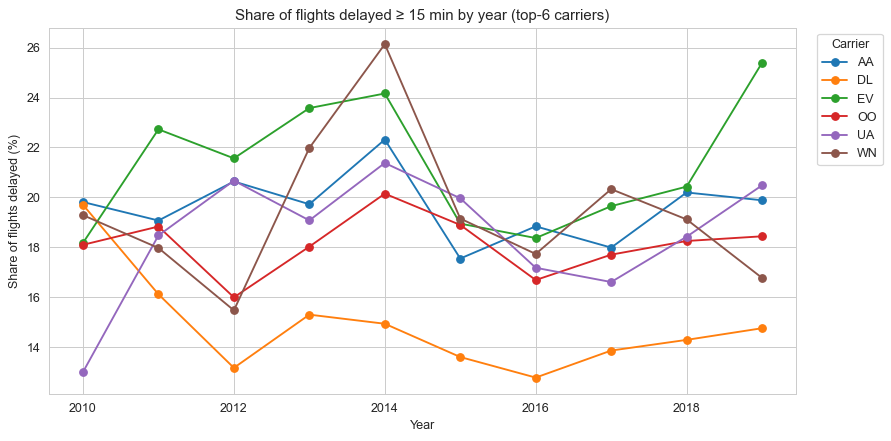

In [26]:
# Plot 15 – yearly delay rate for the top-6 carriers by volume
top6 = df_clean['Reporting_Airline'].value_counts().head(6).index.tolist()
trend = (df_clean[df_clean['Reporting_Airline'].isin(top6)]
           .groupby(['Year', 'Reporting_Airline'])['ArrDel15']
           .mean()
           .unstack('Reporting_Airline') * 100)

plt.figure(figsize=(10, 5))
for c in trend.columns:
    plt.plot(trend.index, trend[c], marker='o', label=c)
plt.title('Share of flights delayed ≥ 15 min by year (top-6 carriers)')
plt.xlabel('Year')
plt.ylabel('Share of flights delayed (%)')
plt.legend(title='Carrier', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Observation.** The carriers move largely in parallel, suggesting that system-wide factors (weather years, congestion) affect everyone simultaneously. **2014** was a particularly bad year for nearly every carrier, while **2012** and **2016** were notably good. The relative *ranking* between carriers is fairly stable across the decade.

### Q16: How do the tail-risk profiles of the top carriers differ?

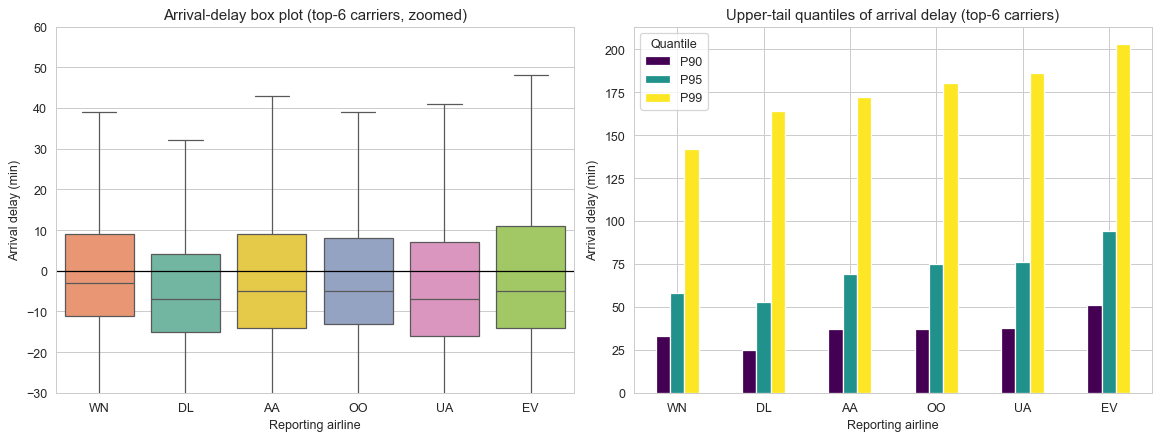

Numerical quantiles per carrier:
                    P90   P95    P99
Reporting_Airline                   
WN                 33.0  58.0  142.0
DL                 25.0  53.0  164.0
AA                 37.0  69.0  172.0
OO                 37.0  75.0  180.0
UA                 38.0  76.0  186.0
EV                 51.0  94.0  203.0


In [27]:
# Plot 16 – carrier-level delay distribution for the top-6 carriers.
#
# A traditional violin / KDE plot is not very informative here because the bulk
# of the distribution is concentrated around 0 and the interesting differences
# live in the **upper tail** (90th–99th percentile). We therefore use TWO
# coordinated views:
#   (a) a box plot with a tight y-range around the IQR, and
#   (b) a bar chart of the 90th / 95th / 99th percentile per carrier, which
#       makes the tail differences directly comparable.
carrier_data = df_clean[df_clean['Reporting_Airline'].isin(top6) &
                        df_clean['ArrDelay'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Box plot, zoomed in to [-30, 60] so median and IQR are clearly visible.
sb.boxplot(data=carrier_data, x='Reporting_Airline', y='ArrDelay',
           order=top6, showfliers=False, ax=axes[0],
           palette='Set2', hue='Reporting_Airline', legend=False)
axes[0].axhline(0, color='black', lw=1)
axes[0].set_ylim(-30, 60)
axes[0].set_title('Arrival-delay box plot (top-6 carriers, zoomed)')
axes[0].set_xlabel('Reporting airline')
axes[0].set_ylabel('Arrival delay (min)')

# (b) Tail percentiles per carrier.
pct = (carrier_data
       .groupby('Reporting_Airline')['ArrDelay']
       .quantile([0.90, 0.95, 0.99])
       .unstack()
       .loc[top6])
pct.columns = ['P90', 'P95', 'P99']
pct.plot(kind='bar', ax=axes[1], colormap='viridis', edgecolor='white')
axes[1].set_title('Upper-tail quantiles of arrival delay (top-6 carriers)')
axes[1].set_xlabel('Reporting airline')
axes[1].set_ylabel('Arrival delay (min)')
axes[1].legend(title='Quantile')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('Numerical quantiles per carrier:')
print(pct.round(1))

**Observation.** A traditional violin / KDE plot is misleading here because the
bulk of the distribution is squashed around 0 and the interesting differences
live in the **upper tail**. The two views above make this explicit:

* **Boxplot (left, zoomed to −30…+60 min):** medians and IQRs are essentially indistinguishable across carriers – every carrier delivers more than half of its flights with a delay of zero or slightly negative. The day-to-day passenger experience is the same.
* **Tail-quantile bars (right):** the picture changes drastically once we look at the worst 10 / 5 / 1 % of flights. **DL** has by far the *best* tail (P90 ≈ 25 min, P99 ≈ 165 min); **EV** has the *worst* (P90 ≈ 51 min, P99 ≈ 200 min) – i.e. EV passengers are roughly twice as likely to experience a 50-minute-or-worse delay than DL passengers.

The carrier ranking on the tail quantiles matches the overall delay-rate ranking from Plot 10 almost exactly. **The difference between a “good” and a “bad” carrier is therefore not the median experience, but the frequency of bad-tail outcomes** – which is exactly what hurts passengers most.

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

The time-of-day and month effects clearly **reinforce each other**: summer evenings and December evenings together produce the worst delay rates in the entire matrix (>30 %). Similarly, the carrier-level decomposition shows that the carriers with the highest overall delay rate also tend to have the largest *late-aircraft* share – i.e. their delays cascade more easily, which is consistent with the time-of-day propagation observed in the bivariate section.

### Were there any interesting or surprising interactions between features?

* The yearly trend lines are **highly synchronised** across carriers – system-wide factors dominate carrier-level efforts.
* Although *weather* is the dominant **cancellation** reason, it is not the dominant **delay-minute** reason at the carrier-aggregated level. Most delay minutes come from carrier-controlled and late-aircraft causes.
* Long-haul flights have *negative* median delays despite intuition to the contrary, because their schedules are padded.

## Conclusions

Working with a 2-million-row sample of the BTS *Reporting Carrier On-Time Performance* dataset, restricted to the decade 2010–2019, I produced 16 visualisations that investigate the distribution of arrival delays and cancellations and how they vary with time, carrier, geography and flight properties.

**Key findings**

1. About **18 % of flights** arrive 15 minutes or more late; only **~1.5 %** are cancelled.
2. The arrival-delay distribution is heavily right-skewed and approximately log-normal in its positive part, motivating the use of `ArrDel15` and median-based summaries.
3. **Time of day** is the strongest single driver of the delay rate – morning departures are dramatically more reliable than evening ones.
4. **Seasonality** matters: summer (Jun–Aug) and December are the worst months. The interaction between month and time of day produces a clear *summer-evening hot-spot* in the heat-map.
5. **Carriers differ substantially** in delay share, but their year-over-year movements are highly synchronised, indicating that system-wide effects dominate carrier-specific operational quality.
6. The biggest contributors to *delay minutes* are **late aircraft** and **carrier-controlled** issues, while **weather** is the leading cause of *cancellations*.
7. Departure delay translates almost one-to-one into arrival delay (r ≈ 0.96), and only minor amounts of slack are recovered in the air. Long-haul flights are an exception thanks to padded schedules.

These findings will be carried into Part II, where the focus will be on communicating the **time-of-day and month interaction** and the **carrier comparison** to a non-technical audience.